**NOTE: This code is designed to run as a Google Colab notebook with associated data loaded into your Google Drive**

In [299]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [299]:
#!pip install gnss_lib_python
%pip install gnss-lib-py --quiet

In [300]:
# setup all the things you need
import numpy as np
import gnss_lib_py as glp
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timezone
from zoneinfo import ZoneInfo

In [301]:
4# import data
# field 1 -- FEAR IT!!!!
field1 = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_11_18_11_29_26.txt"
# field 2 is whole sideline perimeter
field2 = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_11_18_11_21_46.txt"
# field 3 is only fraction of sideline distance
field3 = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_11_18_11_19_48.txt"
oval = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_11_18_11_49_34.txt"
night = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_12_02_20_57_15.txt"

In [302]:
exp = field2

In [303]:
fix_data = glp.AndroidRawFixes(exp)

In [304]:
# check types of fixes collected
fix_types = np.unique(fix_data["fix_provider"]).tolist()
fix_types


[np.str_('fused'), np.str_('gnss'), np.str_('network')]

In [305]:
# extract all 3 fixes
fixes = []
for provider in fix_types:
    fix_provider = fix_data.where("fix_provider",provider)
    fix_provider.rename({"lat_rx_deg":"lat_rx_" + provider + "_deg",
                         "lon_rx_deg":"lon_rx_" + provider + "_deg",
                         "alt_rx_m":"alt_rx_" + provider + "_m",
                         }, inplace=True)
    fixes.append(fix_provider)

In [306]:
# plot fixes
fig_fix = glp.plot_map(*fixes)
fig_fix.show()

In [307]:
# extract raw data; CHANGE input_path for desired exp
raw_data = glp.AndroidRawGnss(input_path=exp,
                              filter_measurements=True,
                              measurement_filters={"sv_time_uncertainty" : 500.},
                              verbose=True)
raw_data.rows

sv_time_uncertainty removed 0


['# Raw',
 'unix_millis',
 'TimeNanos',
 'LeapSecond',
 'TimeUncertaintyNanos',
 'FullBiasNanos',
 'BiasNanos',
 'BiasUncertaintyNanos',
 'DriftNanosPerSecond',
 'DriftUncertaintyNanosPerSecond',
 'HardwareClockDiscontinuityCount',
 'sv_id',
 'TimeOffsetNanos',
 'State',
 'ReceivedSvTimeNanos',
 'ReceivedSvTimeUncertaintyNanos',
 'cn0_dbhz',
 'PseudorangeRateMetersPerSecond',
 'PseudorangeRateUncertaintyMetersPerSecond',
 'AccumulatedDeltaRangeState',
 'accumulated_delta_range_m',
 'accumulated_delta_range_sigma_m',
 'CarrierFrequencyHz',
 'CarrierCycles',
 'CarrierPhase',
 'CarrierPhaseUncertainty',
 'MultipathIndicator',
 'SnrInDb',
 'gnss_id',
 'AgcDb',
 'BasebandCn0DbHz',
 'FullInterSignalBiasNanos',
 'FullInterSignalBiasUncertaintyNanos',
 'SatelliteInterSignalBiasNanos',
 'SatelliteInterSignalBiasUncertaintyNanos',
 'CodeType',
 'ChipsetElapsedRealtimeNanos',
 'IsFullTracking',
 'SvPositionEcefXMeters',
 'SvPositionEcefYMeters',
 'SvPositionEcefZMeters',
 'SvVelocityEcefXMetersPe

In [308]:
full_states = glp.add_sv_states(raw_data, source="precise", verbose=False)

In [309]:
print(full_states)

      # Raw    unix_millis        TimeNanos  LeapSecond  TimeUncertaintyNanos  \
0       Raw  1763493706423  352723185000000          18                   0.0   
1       Raw  1763493706423  352723185000000          18                   0.0   
2       Raw  1763493706423  352723185000000          18                   0.0   
3       Raw  1763493706423  352723185000000          18                   0.0   
4       Raw  1763493706423  352723185000000          18                   0.0   
...     ...            ...              ...         ...                   ...   
18079   Raw  1763494021423  353038185000000          18                   0.0   
18080   Raw  1763494021423  353038185000000          18                   0.0   
18081   Raw  1763494021423  353038185000000          18                   0.0   
18082   Raw  1763494021423  353038185000000          18                   0.0   
18083   Raw  1763494021423  353038185000000          18                   0.0   

             FullBiasNanos 

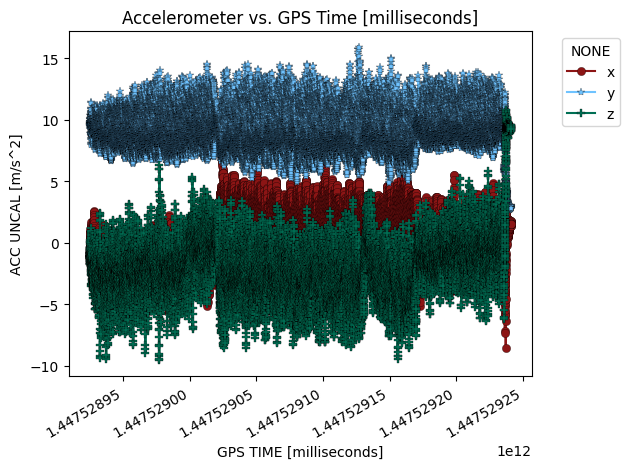

In [310]:
# extract accelerometer data; CHANGE exp name
raw_data_acc = glp.AndroidRawAccel(input_path=exp)
fig = glp.plot_metric(raw_data_acc, "gps_millis","acc_x_uncal_mps2",label="x")
fig = glp.plot_metric(raw_data_acc, "gps_millis","acc_y_uncal_mps2",label="y",fig=fig)
fig = glp.plot_metric(raw_data_acc, "gps_millis","acc_z_uncal_mps2",label="z",fig=fig,
                     title="Accelerometer vs. GPS Time [milliseconds]")
ylabel = plt.ylabel("ACC UNCAL [m/s^2]")

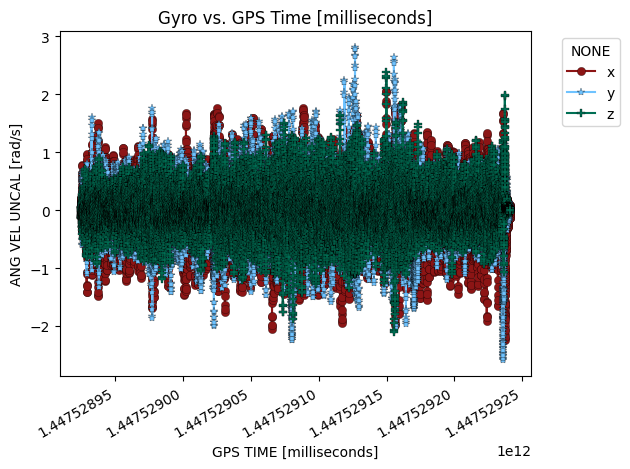

In [311]:
# extract gyro data; CHANGE exp name
raw_data_gyro = glp.AndroidRawGyro(input_path=exp)
fig = glp.plot_metric(raw_data_gyro, "gps_millis","ang_vel_x_uncal_radps",label="x")
fig = glp.plot_metric(raw_data_gyro, "gps_millis","ang_vel_y_uncal_radps",label="y",fig=fig)
fig = glp.plot_metric(raw_data_gyro, "gps_millis","ang_vel_z_uncal_radps",label="z",fig=fig,
                      title="Gyro vs. GPS Time [milliseconds]")
ylabel = plt.ylabel("ANG VEL UNCAL [rad/s]")

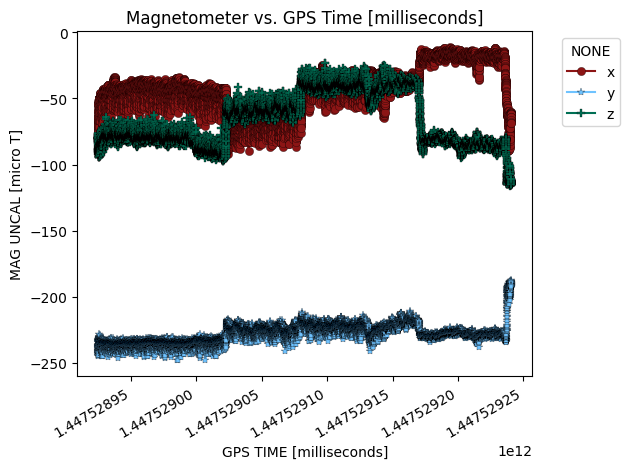

In [312]:
# extract magnetometer data; CHANGE exp name
raw_data_mag = glp.AndroidRawMag(input_path=exp)
fig = glp.plot_metric(raw_data_mag, "gps_millis","mag_x_uncal_microt",label="x")
fig = glp.plot_metric(raw_data_mag, "gps_millis","mag_y_uncal_microt",label="y",fig=fig)
fig = glp.plot_metric(raw_data_mag, "gps_millis","mag_z_uncal_microt",label="z",fig=fig,
                      title="Magnetometer vs. GPS Time [milliseconds]")
ylabel = plt.ylabel("MAG UNCAL [micro T]")

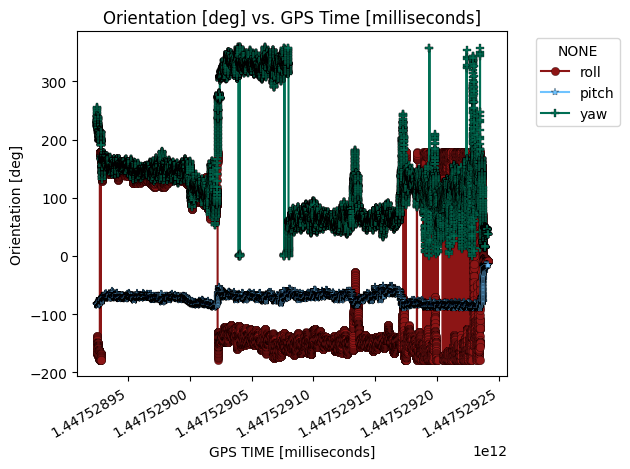

In [313]:
# extract orientation data; CHANGE exp name
raw_data_orient = glp.AndroidRawOrientation(input_path=exp)
fig = glp.plot_metric(raw_data_orient, "gps_millis","roll_rx_deg",label="roll")
fig = glp.plot_metric(raw_data_orient, "gps_millis","pitch_rx_deg",label="pitch",fig=fig)
fig = glp.plot_metric(raw_data_orient, "gps_millis","yaw_rx_deg",label="yaw",fig=fig,
                      title="Orientation [deg] vs. GPS Time [milliseconds]")
ylabel = plt.ylabel("Orientation [deg]")

**Plotting our raw pseudoranges to see how messed up they are before our crop and manual correction**

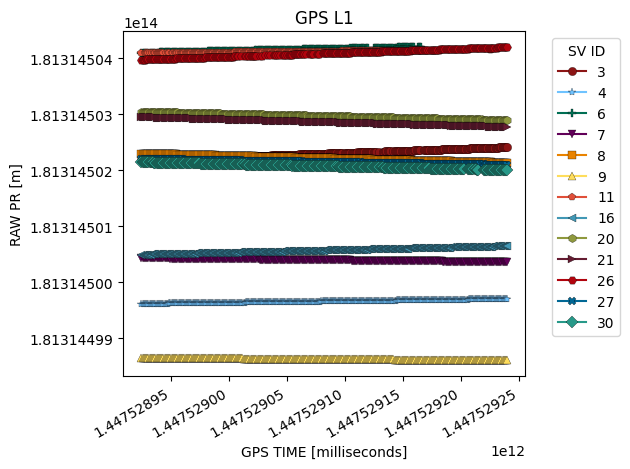

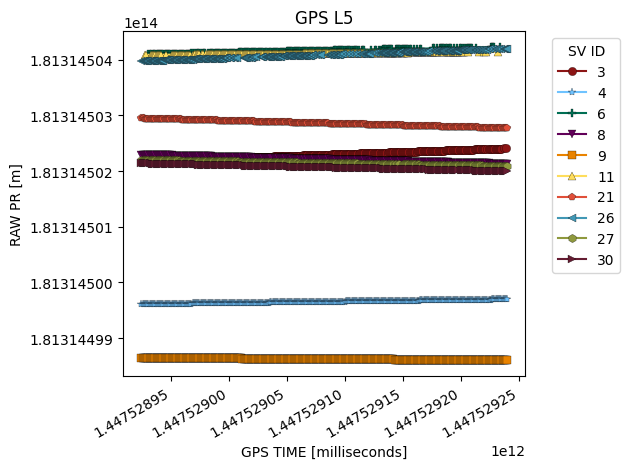

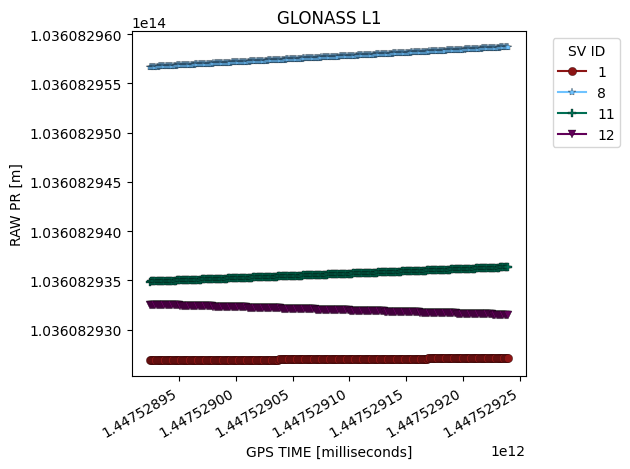

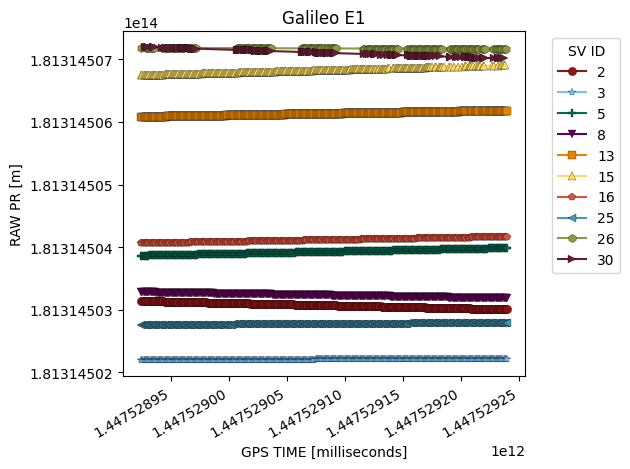

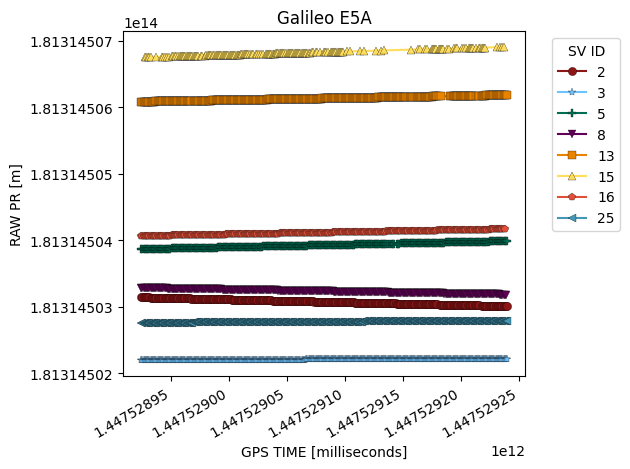

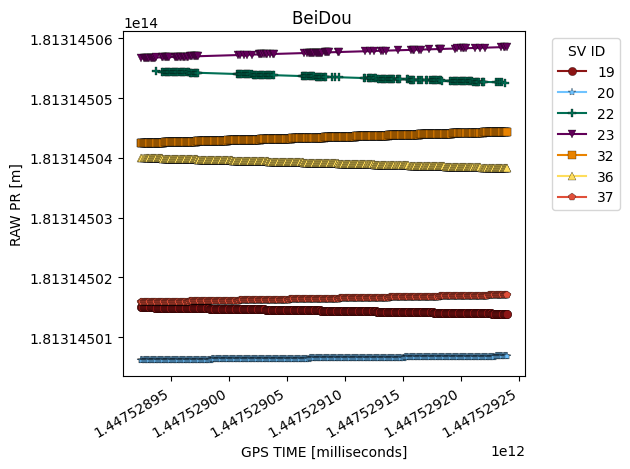

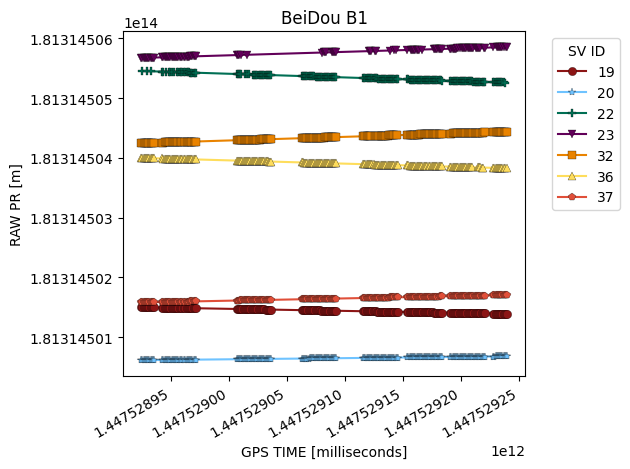

In [314]:
figs = glp.plot_metric_by_constellation(raw_data,"gps_millis","raw_pr_m")

In [315]:
# signal types in the data
print(np.unique(raw_data['signal_type']))

[np.str_('') np.str_('b1') np.str_('e1') np.str_('e5a') np.str_('l1')
 np.str_('l5')]


**Correcting our raw pseudorange**

In [316]:
# # crop full states to only GPS
# full_states = full_states.where("gnss_id",("gps"))

In [317]:
# crop full states to GPS and Galileo
full_states = full_states.where("gnss_id",("gps","galileo"))

In [318]:
print(full_states["raw_pr_m"])

[1.81314502e+14 1.81314500e+14 1.81314504e+14 ... 1.81314504e+14
 1.81314506e+14 1.81314503e+14]


In [319]:
# # we want to get an accurate corr_pr_m column for full_states before we can pass to the ekf function
# # our raw_pr_m measurements are wrong, so first lets correct them against the clock bias then put them back into the NavData class
# fields = ['unix_millis', 'gnss_id', 'sv_id', 'TimeNanos', 'FullBiasNanos', 'TimeOffsetNanos', 'BiasNanos', 'ReceivedSvTimeNanos', 'b_sv_m', 'x_sv_m', 'y_sv_m', 'z_sv_m']
# data_dict = {k: full_states[k] for k in fields}
# df = pd.DataFrame(data_dict)
# # print(df)

# from scipy.constants import c

# # Receiver GNSS time in seconds (subtract biases)
# t_Rx_s = (df['TimeNanos'] - (df['FullBiasNanos'] + df['BiasNanos'])) * 1e-9

# # Satellite transmit time in seconds
# t_Tx_s = df['ReceivedSvTimeNanos'] * 1e-9

# # Align satellite times to same GPS week as receiver
# gps_week_s = 604800
# t_Tx_aligned = t_Tx_s + np.floor(t_Rx_s / gps_week_s) * gps_week_s

# # Compute pseudoranges in meters
# df['pr_m'] = (t_Rx_s - t_Tx_aligned) * c

# # print(df)
# print(df['pr_m'])

In [320]:
# this is specifically for GPS and Galileo combined to avoid differences between the two
# we want to get an accurate corr_pr_m column for full_states before we can pass to the ekf function
# our raw_pr_m measurements are wrong, so first lets correct them against the clock bias then put them back into the NavData class
fields = ['unix_millis', 'gnss_id', 'sv_id', 'TimeNanos', 'FullBiasNanos', 'TimeOffsetNanos', 'BiasNanos', 'ReceivedSvTimeNanos', 'b_sv_m', 'x_sv_m', 'y_sv_m', 'z_sv_m']
data_dict = {k: full_states[k] for k in fields}
df = pd.DataFrame(data_dict)
# print(df)

c = 299792458. # m/s

# Receiver GNSS time in seconds (subtract biases)
t_Rx_s = (df['TimeNanos'] - (df['FullBiasNanos'] + df['BiasNanos'])) * 1e-9

# Satellite transmit time in seconds
t_Tx_s = df['ReceivedSvTimeNanos'] * 1e-9

GGT0 = 40e-9 # correction factor between Galileo and GPS constellations

t_Tx_gps_s = np.where(
    df['gnss_id'].values == 'galileo',
    t_Tx_s + GGT0,
    t_Tx_s
)

# Align satellite times to same GPS week as receiver
gps_week_s = 604800
t_Tx_aligned = t_Tx_gps_s + np.floor(t_Rx_s / gps_week_s) * gps_week_s

# gps_millis_corr = t_Tx_aligned * 1e3

# Compute pseudoranges in meters
df['pr_m'] = (t_Rx_s - t_Tx_aligned) * c

# print(df)
print(df['pr_m'])

0        2.358089e+07
1        2.101211e+07
2        2.549509e+07
3        2.182780e+07
4        2.369597e+07
             ...     
12071    2.440773e+07
12072    2.361892e+07
12073    2.538616e+07
12074    2.758270e+07
12075    2.419115e+07
Name: pr_m, Length: 12076, dtype: float64


In [321]:
# pull the new raw pseudoranges as a numpy array
pr = df['pr_m'].to_numpy()
# print(pr)

# replace the incorrect raw_pr_m in full_states with the new raw_states
full_states['raw_pr_m'] = pr
# full_states['raw_pr_m']

In [322]:
print(full_states['raw_pr_m'])

[23580891.89437723 21012112.6289587  25495093.11052608 ...
 25386163.54652882 27582695.32553148 24191154.76669264]


**EKF with .txt**

In [323]:
# I'm going to do a messy psuedorange correction of just raw_pr_m + b_sv_m
# then I'm going to call the GNSS EKF function to get an initial state estimate
# to use for a better pseudorange correction function later with iono and tropo delays
full_states["corr_pr_m"] = full_states["raw_pr_m"] + full_states['b_sv_m']

In [324]:
# before I try to solve the ekf, I have to apply the sagnac correction to the data because
# the ekf doesn't do it natively
from gnss_lib_py.utils import constants as consts

def apply_sagnac_correction(navdata):
    """
    Apply Sagnac (Earth rotation) correction to satellite positions in a NavData object
    in a fully vectorized manner using a DataFrame.

    Parameters
    ----------
    navdata : NavData
        The NavData object containing satellite positions and pseudoranges.

    Returns
    -------
    navdata_corrected : NavData
        A copy of the input NavData with satellite positions corrected for Earth's rotation.
    """
    # Copy the NavData object
    navdata_corrected = navdata.copy()

    # Convert relevant fields to DataFrame
    fields = ['x_sv_m', 'y_sv_m', 'z_sv_m', 'corr_pr_m']
    df = pd.DataFrame({k: navdata_corrected[k] for k in fields})

    # Receiver clock bias (assume unknown, set to 0)
    b_rx = 0.0

    # Compute signal travel time
    delta_t = (df['corr_pr_m'] - b_rx) / consts.C  # seconds

    # Compute Earth rotation angle
    dtheta = consts.OMEGA_E_DOT * delta_t  # radians

    # Rotate satellite positions in x-y plane
    x_rot = np.cos(dtheta) * df['x_sv_m'] + np.sin(dtheta) * df['y_sv_m']
    y_rot = -np.sin(dtheta) * df['x_sv_m'] + np.cos(dtheta) * df['y_sv_m']
    z_rot = df['z_sv_m']  # z unchanged

    # Assign back to NavData
    navdata_corrected['x_sv_m'] = x_rot.to_numpy().reshape(1, -1)
    navdata_corrected['y_sv_m'] = y_rot.to_numpy().reshape(1, -1)
    navdata_corrected['z_sv_m'] = z_rot.to_numpy().reshape(1, -1)

    return navdata_corrected

In [325]:
full_states_sagnac = apply_sagnac_correction(full_states)

In [326]:
# state_ekf = glp.solve_gnss_ekf(full_states)
state_ekf = glp.solve_gnss_ekf(full_states_sagnac)

In [327]:
# glp.plot_map(state_ekf)

In [328]:
state_ekf.rows
# print(state_ekf)

['gps_millis',
 'x_rx_ekf_m',
 'y_rx_ekf_m',
 'z_rx_ekf_m',
 'vx_rx_ekf_mps',
 'vy_rx_ekf_mps',
 'vz_rx_ekf_mps',
 'b_rx_ekf_m',
 'lat_rx_ekf_deg',
 'lon_rx_ekf_deg',
 'alt_rx_ekf_m']

In [329]:
# pull the ionospheric parameters from the full_states object and reconstruct the Klobucher values into a 2x4 np.ndarray
# this code only takes the mean of the ionospheric coefficients
iono_params = {
    "gps" : np.array([
        [ full_states['KlobucharAlpha0'].mean(),
          full_states['KlobucharAlpha1'].mean(),
          full_states['KlobucharAlpha2'].mean(),
          full_states['KlobucharAlpha3'].mean() ],

        [ full_states['KlobucharBeta0'].mean(),
          full_states['KlobucharBeta1'].mean(),
          full_states['KlobucharBeta2'].mean(),
          full_states['KlobucharBeta3'].mean() ]
    ])
}


In [330]:
# pull the very first state values from the first state_ekf solution, this will be our initial guess to calculate the iono and tropo delays
for col_idx, nav_data_col in enumerate(state_ekf):
  initial_state_parameter = nav_data_col
  if col_idx >= 1:
    break
# print(initial_state_parameter)

# add the receiver clock bias rate manually, in this case we will assume that it is zero
initial_state_parameter['b_dot_rx_guess_mps'] = 0
print(initial_state_parameter)

     gps_millis    x_rx_ekf_m    y_rx_ekf_m    z_rx_ekf_m  vx_rx_ekf_mps  \
0  1.447529e+12 -2.698931e+06 -4.293176e+06  3.855507e+06       0.013075   

   vy_rx_ekf_mps  vz_rx_ekf_mps  b_rx_ekf_m  lat_rx_ekf_deg  lon_rx_ekf_deg  \
0       0.019275       0.005669   27.916733       37.431199      -122.15577   

   alt_rx_ekf_m  b_dot_rx_guess_mps  
0      5.882472                   0  


In [331]:
# now calculate the corr_pr_m with the calculate_pseudorange_corr
tropo_delay_m, iono_delay_m = glp.calculate_pseudorange_corr(full_states["gps_millis"], state=initial_state_parameter, ephem=None, sv_posvel=full_states, iono_params=iono_params)

In [332]:
print(tropo_delay_m)
print(iono_delay_m)

[ 6.89091526  2.96710238 25.24136619 ...  7.14251975 10.79941024
  2.99721663]
[11.7961473   5.92273529 13.81659698 ... 11.83072262 11.62213984
  5.96828593]


In [333]:
atmospheric_full_states = full_states.copy()
atmospheric_full_states_sagnac = full_states_sagnac.copy()

In [334]:
# now we need to add the iono and tropo delays into the full_states NavData class object
atmospheric_full_states["iono_delay_m"] = iono_delay_m
atmospheric_full_states["tropo_delay_m"] = tropo_delay_m
# print(full_states)
# FORMULA: corr_pr_m = raw_pr_m + b_sv_m - intersignal_bias_m - iono_delay_m - tropo_delay_m
# then use those states with the following formula to calculate a better corr_pr_m
atmospheric_full_states["corr_pr_m"] = atmospheric_full_states["raw_pr_m"] + atmospheric_full_states['b_sv_m'] - atmospheric_full_states['iono_delay_m'] - atmospheric_full_states['tropo_delay_m']
print(full_states["corr_pr_m"])
print(atmospheric_full_states["corr_pr_m"])

[23773321.72775056 21019667.43098688 25322868.78219328 ...
 26855441.34585655 27569725.84603173 24197563.46980852]
[23773303.040688   21019658.54114921 25322829.72423011 ...
 26855422.37261418 27569703.42448164 24197554.50430596]


In [335]:
# now we need to add the iono and tropo delays into the full_states_sagnac NavData class object
atmospheric_full_states_sagnac["iono_delay_m"] = iono_delay_m
atmospheric_full_states_sagnac["tropo_delay_m"] = tropo_delay_m
# print(full_states)
# FORMULA: corr_pr_m = raw_pr_m + b_sv_m - intersignal_bias_m - iono_delay_m - tropo_delay_m
# then use those states with the following formula to calculate a better corr_pr_m
atmospheric_full_states_sagnac["corr_pr_m"] = atmospheric_full_states_sagnac["raw_pr_m"] + atmospheric_full_states_sagnac['b_sv_m'] - atmospheric_full_states_sagnac['iono_delay_m'] - atmospheric_full_states_sagnac['tropo_delay_m']
print(full_states["corr_pr_m"])
print(atmospheric_full_states_sagnac["corr_pr_m"])

[23773321.72775056 21019667.43098688 25322868.78219328 ...
 26855441.34585655 27569725.84603173 24197563.46980852]
[23773303.040688   21019658.54114921 25322829.72423011 ...
 26855422.37261418 27569703.42448164 24197554.50430596]


In [336]:
# calculate time steps of data
t_ms = np.unique(atmospheric_full_states['gps_millis'])
dts = np.diff(np.sort(t_ms)) / 1000.0 # seconds
dt_nominal = np.median(dts)
# print(dt_nominal)

In [337]:
# sigma_a = 0.5 # acceleration noise of walking, m/s^2
# S_b = 100 # conservative clock bias estimate, m^2/s
def make_Q(dt, sigma_a=0.5, sigma_b_psd=100.0):
  S_a = sigma_a**2 # covariance matrix
  q11 = S_a * dt**3 / 3.0
  q12 = S_a * dt**2 / 2.0
  q22 = S_a * dt
  Q = np.zeros((7,7))
  for i in range(3):
    Q[i,i] = q11
    Q[i,i+3] = q12
    Q[i+3,i] = q12
    Q[i+3,i+3] = q22
  # clock bias based on walking during data collection
  Q[6,6] = sigma_b_psd * dt
  return Q

In [338]:
# these initial values are just random weights assigned to pos, v and time
def make_P0(position_std=20.0, velocity_std=2.0, clock_std=100.0):
# def make_P0(position_std=20.0, velocity_std=5.0, clock_std=1000.0):
# def make_P0(position_std=5.0, velocity_std=0.1, clock_std=100.0):
    """Create diagonal P0 given stds."""
    P0 = np.diag([
        position_std**2, position_std**2, position_std**2,
        velocity_std**2, velocity_std**2, velocity_std**2,
        clock_std**2
    ])
    return P0

In [339]:
# run ekf with a custom R and Q matrix
# init_dict has state_0, sigma_0, R and Q

Q = make_Q(dt_nominal)
sigma_0 = make_P0()
init_dict = {"sigma_0": sigma_0, "Q": Q}
# print(Q)
# print(sigma_0)

In [340]:
state_ekf_corr = glp.solve_gnss_ekf(atmospheric_full_states_sagnac, init_dict=init_dict,
                                    params_dict=None)

In [341]:
# now lets run and plot the ekf again but with a more accurate corrected pseudorange that takes atmospheric delay into account:
# state_ekf_corr = glp.solve_gnss_ekf(atmospheric_full_states)
# state_ekf_corr = glp.solve_gnss_ekf(atmospheric_full_states_sagnac)

In [342]:
state_ekf_corr.rows

['gps_millis',
 'x_rx_ekf_m',
 'y_rx_ekf_m',
 'z_rx_ekf_m',
 'vx_rx_ekf_mps',
 'vy_rx_ekf_mps',
 'vz_rx_ekf_mps',
 'b_rx_ekf_m',
 'lat_rx_ekf_deg',
 'lon_rx_ekf_deg',
 'alt_rx_ekf_m']

In [343]:
# rename lat and long values to something slightly different so we can look at both values on the same plot as the previous ekf
state_ekf_corr['lat_rx_correkf_deg'] = state_ekf_corr['lat_rx_ekf_deg']
state_ekf_corr['lon_rx_correkf_deg'] = state_ekf_corr['lon_rx_ekf_deg']
# remove the old rows
state_ekf_corr = state_ekf_corr.remove(rows = ["lat_rx_ekf_deg", 'lon_rx_ekf_deg'])

In [344]:
# glp.plot_map(state_ekf_corr)

In [345]:
glp.plot_map(state_ekf, state_ekf_corr)

**Default WLS with .txt file and a corr_pr_m that accounts for receiver clock bias, iono and tropo delays**


In [346]:
# calculate WLS estimate
wls_estimate = glp.solve_wls(full_states)
# wls_estimate = glp.solve_wls(full_states, sv_rx_time=True)

In [347]:
# plot data
# glp.plot_map(wls_estimate)

In [348]:
# calculate WLS estimate with atmospheric delays
wls_estimate_atmosphere = glp.solve_wls(atmospheric_full_states)
# wls_estimate_atmosphere = glp.solve_wls(atmospheric_full_states, sv_rx_time=True)
# plot data
# glp.plot_map(wls_estimate_atmosphere)

In [349]:
# rename lat and long values to something slightly different so we can look at both values on the same plot as the previous wls
wls_estimate_atmosphere['lat_rx_corrwls_deg'] = wls_estimate_atmosphere['lat_rx_wls_deg']
wls_estimate_atmosphere['lon_rx_corrwls_deg'] = wls_estimate_atmosphere['lon_rx_wls_deg']
# remove the old rows
wls_estimate_atmosphere = wls_estimate_atmosphere.remove(rows = ["lat_rx_wls_deg", 'lon_rx_wls_deg'])

In [350]:
glp.plot_map(wls_estimate, wls_estimate_atmosphere)

***NMEA DATA VISUALIZATION***

In [351]:
4# import NMEA data
# field 1 -- FEAR IT!!!!
field1 = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_11_18_11_29_26.nmea"
# field 2 is whole sideline perimeter
field2 = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_11_18_11_21_46.nmea"
# field 3 is only fraction of sideline distance
field3 = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_11_18_11_19_48.nmea"
oval = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_11_18_11_49_34.nmea"
night = "/content/drive/MyDrive/Pretty Picture Project/Data/gnss_log_2025_12_02_20_57_15.nmea"

In [352]:
nmea_data = glp.Nmea(field2)

In [353]:
nmea_data.rows

['lat_rx_deg',
 'lon_rx_deg',
 'status',
 'vx_rx_mps',
 'heading_raw_rx_deg',
 'gps_qual',
 'num_sats',
 'horizontal_dil',
 'alt_rx_m',
 'altitude_units',
 'geo_sep',
 'geo_sep_units',
 'age_gps_data',
 'ref_station_id',
 'gps_millis',
 'heading_rx_rad']

In [354]:
nmea_fig = glp.plot_map(nmea_data)
nmea_fig.show()

In [355]:
nmea_data.rows

['lat_rx_deg',
 'lon_rx_deg',
 'status',
 'vx_rx_mps',
 'heading_raw_rx_deg',
 'gps_qual',
 'num_sats',
 'horizontal_dil',
 'alt_rx_m',
 'altitude_units',
 'geo_sep',
 'geo_sep_units',
 'age_gps_data',
 'ref_station_id',
 'gps_millis',
 'heading_rx_rad']

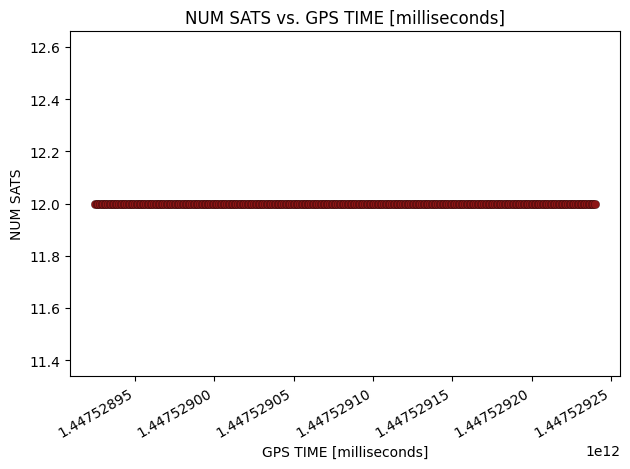

In [356]:
fig = glp.plot_metric(nmea_data,"gps_millis","num_sats")

Now let's do EKF and WLS with a cropped elevation mask (and atmospheric corrections)

In [357]:
# print(atmospheric_full_states)

In [358]:
navstates = glp.add_el_az(navdata=atmospheric_full_states, receiver_state=wls_estimate_atmosphere, inplace=True)
navstates_sagnac = glp.add_el_az(navdata=atmospheric_full_states_sagnac, receiver_state=wls_estimate_atmosphere, inplace=True)

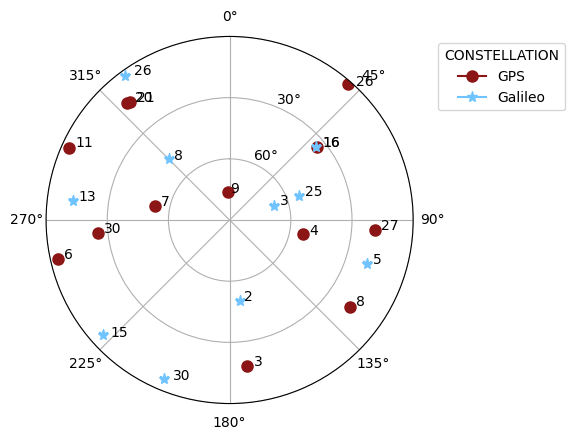

In [359]:
fig = glp.plot_skyplot(navstates,wls_estimate_atmosphere)

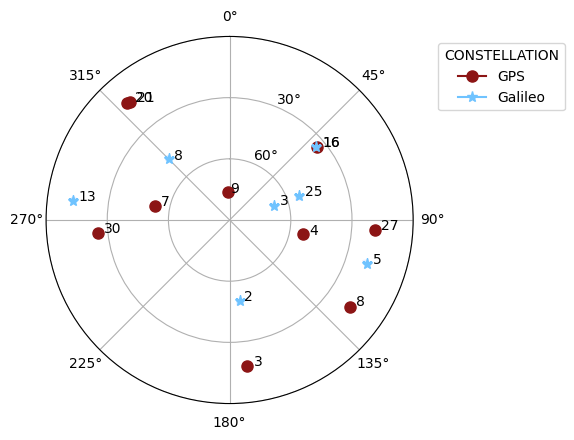

In [360]:
cropped_navstates = navstates.where("el_sv_deg",10.,"geq")
fig = glp.plot_skyplot(cropped_navstates,wls_estimate_atmosphere)
cropped_navstates_sagnac = navstates_sagnac.where("el_sv_deg",10.,"geq")

**WLS estimate with cropped elevation**

In [361]:
wls_estimate_el_mask = glp.solve_wls(cropped_navstates)
# wls_estimate_el_mask = glp.solve_wls(cropped_navstates, sv_rx_time=True)
# plot data
# glp.plot_map(wls_estimate_el_mask)

In [362]:
# rename lat and long values to something slightly different so we can look at both values on the same plot as the previous wls
wls_estimate_el_mask['lat_rx_elmaskwls_deg'] = wls_estimate_el_mask['lat_rx_wls_deg']
wls_estimate_el_mask['lon_rx_elmaskwls_deg'] = wls_estimate_el_mask['lon_rx_wls_deg']
# remove the old rows
wls_estimate_el_mask = wls_estimate_el_mask.remove(rows = ["lat_rx_wls_deg", 'lon_rx_wls_deg'])

In [363]:
glp.plot_map(wls_estimate, wls_estimate_atmosphere, wls_estimate_el_mask, nmea_data)

**EKF estimate with cropped elevation**

In [364]:
# state_ekf_el_mask = glp.solve_gnss_ekf(cropped_navstates)
state_ekf_el_mask = glp.solve_gnss_ekf(cropped_navstates_sagnac, init_dict)
# plot
# glp.plot_map(state_ekf_el_mask)

In [365]:
# rename lat and long values to something slightly different so we can look at both values on the same plot as the previous ekf
state_ekf_el_mask['lat_rx_elmaskekf_deg'] = state_ekf_el_mask['lat_rx_ekf_deg']
state_ekf_el_mask['lon_rx_elmaskekf_deg'] = state_ekf_el_mask['lon_rx_ekf_deg']
# remove the old rows
state_ekf_el_mask = state_ekf_el_mask.remove(rows = ["lat_rx_ekf_deg", 'lon_rx_ekf_deg'])

In [384]:
glp.plot_map(state_ekf, state_ekf_corr, state_ekf_el_mask, nmea_data)

**Skyplots of satellites in view at time of data collection**

ephemeris dates needed: [datetime.date(2025, 12, 3)]
using previously downloaded file:
 /content/data/ephemeris/sp3/GFZ0MGXRAP_20253370000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/GFZ0MGXRAP_20253370000_01D_05M_ORB.SP3


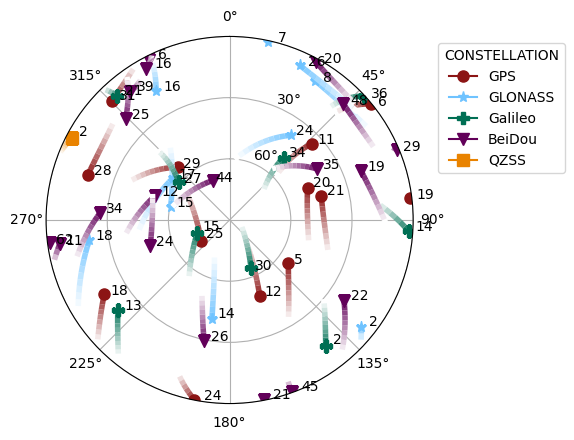

In [367]:
# # This is for the field specifically
# lat, lon, alt = 37.43109060346768, -122.15524075735037, 0.
# This is for the oval specifically
lat, lon, alt = 37.430871105248864, -122.16913436591264, 0.
# timestamp_start = datetime(year=2025, month=11, day=18, hour=11, tzinfo=ZoneInfo("America/Los_Angeles"))
# timestamp_end = datetime(year=2025, month=11, day=18, hour=12, tzinfo=ZoneInfo("America/Los_Angeles"))
# this is at nighttime
timestamp_start = datetime(year=2025, month=12, day=2, hour=20, tzinfo=ZoneInfo("America/Los_Angeles"))
timestamp_end = datetime(year=2025, month=12, day=2, hour=21, tzinfo=ZoneInfo("America/Los_Angeles"))

gps_millis = glp.datetime_to_gps_millis(np.array([timestamp_start,timestamp_end]))
sp3_path = glp.load_ephemeris(file_type="sp3",
                              gps_millis=gps_millis,
                              verbose=True)

# load the sp3 file
sp3 = glp.Sp3(sp3_path)

# create receiver state NavData instance to pass into skyplot function
x_rx_m, y_rx_m, z_rx_m = glp.geodetic_to_ecef(np.array([[lat,lon,alt]]))[0]
receiver_state = glp.NavData()
receiver_state["gps_millis"] = glp.datetime_to_gps_millis(timestamp_start)
receiver_state["x_rx_m"] = x_rx_m
receiver_state["y_rx_m"] = y_rx_m
receiver_state["z_rx_m"] = z_rx_m
cropped_sp3 = sp3.where("gps_millis",gps_millis[0],"geq").where("gps_millis",gps_millis[1],"leq")
fig = glp.plot_skyplot(cropped_sp3,receiver_state)

ephemeris dates needed: [datetime.date(2025, 12, 3)]
using previously downloaded file:
 /content/data/ephemeris/sp3/GFZ0MGXRAP_20253370000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/GFZ0MGXRAP_20253370000_01D_05M_ORB.SP3


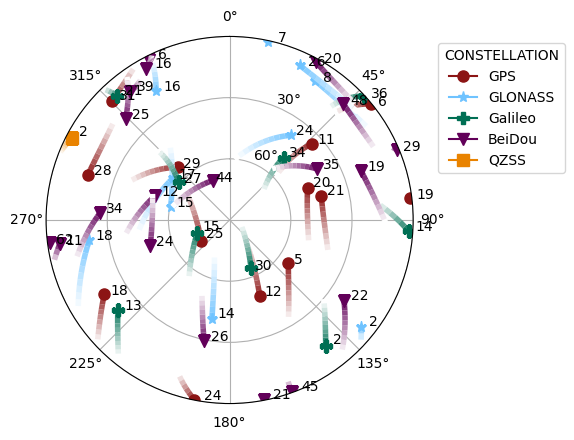

In [368]:
# This is for the oval specifically
lat, lon, alt = 37.430871105248864, -122.16913436591264, 0.
# this is for the data collected during the day:
# timestamp_start = datetime(year=2025, month=11, day=18, hour=11, tzinfo=ZoneInfo("America/Los_Angeles"))
# timestamp_end = datetime(year=2025, month=11, day=18, hour=12, tzinfo=ZoneInfo("America/Los_Angeles"))
# this is for the data collected at night
timestamp_start = datetime(year=2025, month=12, day=2, hour=20, tzinfo=ZoneInfo("America/Los_Angeles"))
timestamp_end = datetime(year=2025, month=12, day=2, hour=21, tzinfo=ZoneInfo("America/Los_Angeles"))

gps_millis = glp.datetime_to_gps_millis(np.array([timestamp_start,timestamp_end]))
sp3_path = glp.load_ephemeris(file_type="sp3",
                              gps_millis=gps_millis,
                              verbose=True)

# load the sp3 file
sp3 = glp.Sp3(sp3_path)

# create receiver state NavData instance to pass into skyplot function
x_rx_m, y_rx_m, z_rx_m = glp.geodetic_to_ecef(np.array([[lat,lon,alt]]))[0]
receiver_state = glp.NavData()
receiver_state["gps_millis"] = glp.datetime_to_gps_millis(timestamp_start)
receiver_state["x_rx_m"] = x_rx_m
receiver_state["y_rx_m"] = y_rx_m
receiver_state["z_rx_m"] = z_rx_m
cropped_sp3 = sp3.where("gps_millis",gps_millis[0],"geq").where("gps_millis",gps_millis[1],"leq")
fig = glp.plot_skyplot(cropped_sp3,receiver_state)

**Error histogram plotting**

In [369]:
nmea_data.rows

['lat_rx_deg',
 'lon_rx_deg',
 'status',
 'vx_rx_mps',
 'heading_raw_rx_deg',
 'gps_qual',
 'num_sats',
 'horizontal_dil',
 'alt_rx_m',
 'altitude_units',
 'geo_sep',
 'geo_sep_units',
 'age_gps_data',
 'ref_station_id',
 'gps_millis',
 'heading_rx_rad']

In [370]:
wls_estimate_el_mask.rows

['gps_millis',
 'x_rx_wls_m',
 'y_rx_wls_m',
 'z_rx_wls_m',
 'b_rx_wls_m',
 'alt_rx_wls_m',
 'lat_rx_elmaskwls_deg',
 'lon_rx_elmaskwls_deg']

In [371]:
def error_histogram(ground_truth, estimate):
    """Plot histogram of errors in meters."""

    R = 6378137  # Earth radius in meters

    # extract data
    gt_idxs = [i[0] for i in glp.find_wildcard_indexes(
        ground_truth, ["lat_rx*_deg", "lon_rx*_deg", 'alt_rx*_m'], max_allow=1).values()]
    est_idxs = [i[0] for i in glp.find_wildcard_indexes(
        estimate, ["lat_rx_*_deg","lon_rx_*_deg", 'alt_rx_*_m'], max_allow=1).values()]

    gt = ground_truth[gt_idxs]
    est = estimate[est_idxs]

    # Differences in degrees/meters
    dlat = (gt[0,:] - est[0,:]) * np.pi/180 * R
    dlon = (gt[1,:] - est[1,:]) * np.pi/180 * R * np.cos(np.deg2rad(gt[0,:]))
    dalt = (gt[2,:] - est[2,:])  # already in meters

    # Total error magnitude
    errors = np.sqrt(dlat**2 + dlon**2 + dalt**2)

    # find the mean of the total error
    mean_total_error = np.mean(errors)

    # ---- Plot histograms ----
    fig, axs = plt.subplots(2,2)

    plt.subplot(221)
    plt.hist(errors, bins=50)
    plt.title("Total Error [m]")
    # xmin, xmax = plt.xlim()
    # plt.xticks(np.arange(xmin, xmax+1, 10))   # step size = 10

    plt.subplot(222)
    plt.hist(dlat,bins=50)
    plt.title("North Error [m]")

    plt.subplot(223)
    plt.hist(dlon,bins=50)
    plt.title("East Error [m]")

    plt.subplot(224)
    plt.hist(dalt,bins=50)
    plt.title("Down Error [m]")

    plt.tight_layout()

    # 2D error plot
    plt.figure()
    plt.hist2d(dlon, dlat, bins=50, cmin=1)
    plt.xlabel("East Error [m]")
    plt.ylabel("North Error [m]")
    plt.title("2D Position Error Density")
    plt.colorbar()

    stats = {
        "RMSE_total": np.sqrt(np.mean(errors**2)),
        "RMSE_north": np.sqrt(np.mean(dlat**2)),
        "RMSE_east": np.sqrt(np.mean(dlon**2)),
        "mean_N": np.mean(dlat),
        "mean_E": np.mean(dlon),
        "mean_D": np.mean(dalt),
        "std_N": np.std(dlat),
        "std_E": np.std(dlon),
        "std_D": np.std(dalt),
        "max_error": np.max(errors),
        "num_samples": errors.size


    }

    stats["mean_total"] = np.mean(errors)
    stats["std_total"] = np.std(errors)


    latex_table = r"""
  \begin{table}[h]
  \centering
  \begin{tabular}{lccc}
  \hline
  \textbf{Statistic} & \textbf{North [m]} & \textbf{East [m]} & \textbf{Down [m]} \\
  \hline
  RMSE & %.3f & %.3f & %.3f \\
  Mean Bias & %.3f & %.3f & %.3f \\
  Std Dev & %.3f & %.3f & %.3f \\
  \hline
  \multicolumn{4}{c}{\textbf{Total 3D Error Statistics}} \\
  \hline
  RMSE$_{3D}$ & \multicolumn{3}{c}{%.3f} \\
  Mean$_{3D}$ & \multicolumn{3}{c}{%.3f} \\
  Std Dev$_{3D}$ & \multicolumn{3}{c}{%.3f} \\
  Max Error & \multicolumn{3}{c}{%.3f} \\
  Samples & \multicolumn{3}{c}{%d} \\
  \hline
  \end{tabular}
  \caption{Positioning Error Statistics in NED and 3D}
  \end{table}
  """ % (
        stats["RMSE_north"], stats["RMSE_east"], stats["RMSE_total"],
        stats["mean_N"], stats["mean_E"], stats["mean_D"],
        stats["std_N"], stats["std_E"], stats["std_D"],
        stats["RMSE_total"],
        stats["mean_total"],
        stats["std_total"],
        stats["max_error"],
        stats["num_samples"],
    )

    print(latex_table)




    return fig, mean_total_error, latex_table, stats



  \begin{table}[h]
  \centering
  \begin{tabular}{lccc}
  \hline
  \textbf{Statistic} & \textbf{North [m]} & \textbf{East [m]} & \textbf{Down [m]} \\
  \hline
  RMSE & 14.306 & 13.398 & 50.321 \\
  Mean Bias & -8.753 & -9.895 & 43.093 \\
  Std Dev & 11.316 & 9.032 & 17.058 \\
  \hline
  \multicolumn{4}{c}{\textbf{Total 3D Error Statistics}} \\
  \hline
  RMSE$_{3D}$ & \multicolumn{3}{c}{50.321} \\
  Mean$_{3D}$ & \multicolumn{3}{c}{47.825} \\
  Std Dev$_{3D}$ & \multicolumn{3}{c}{15.651} \\
  Max Error & \multicolumn{3}{c}{86.611} \\
  Samples & \multicolumn{3}{c}{316} \\
  \hline
  \end{tabular}
  \caption{Positioning Error Statistics in NED and 3D}
  \end{table}
  
Mean total error is: 47.825061635245234


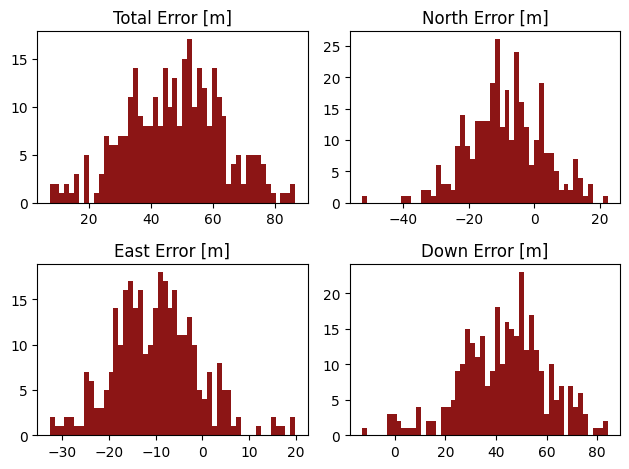

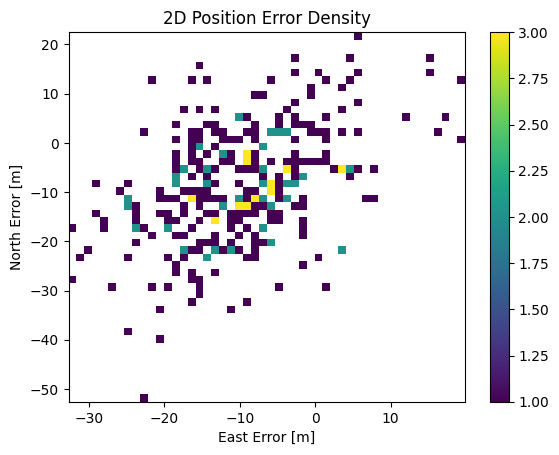

In [372]:
fig, mean_total_error, latex_table, stats = error_histogram(nmea_data, wls_estimate_atmosphere)
print(f"Mean total error is: {mean_total_error}")


  \begin{table}[h]
  \centering
  \begin{tabular}{lccc}
  \hline
  \textbf{Statistic} & \textbf{North [m]} & \textbf{East [m]} & \textbf{Down [m]} \\
  \hline
  RMSE & 14.306 & 13.397 & 50.317 \\
  Mean Bias & -8.753 & -9.895 & 43.093 \\
  Std Dev & 11.316 & 9.031 & 17.048 \\
  \hline
  \multicolumn{4}{c}{\textbf{Total 3D Error Statistics}} \\
  \hline
  RMSE$_{3D}$ & \multicolumn{3}{c}{50.317} \\
  Mean$_{3D}$ & \multicolumn{3}{c}{47.823} \\
  Std Dev$_{3D}$ & \multicolumn{3}{c}{15.644} \\
  Max Error & \multicolumn{3}{c}{86.567} \\
  Samples & \multicolumn{3}{c}{316} \\
  \hline
  \end{tabular}
  \caption{Positioning Error Statistics in NED and 3D}
  \end{table}
  
Mean total error is: 47.823287370671515


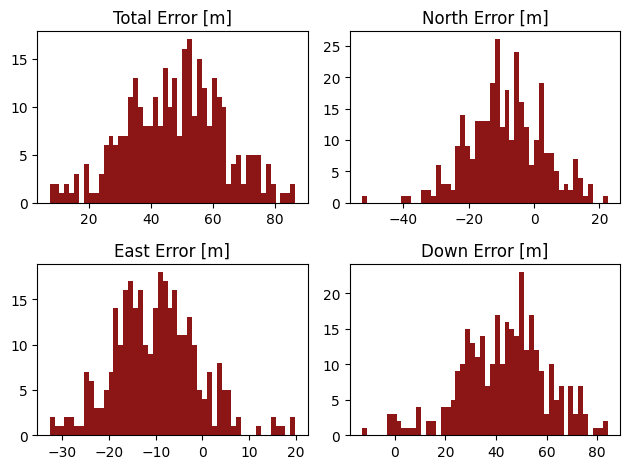

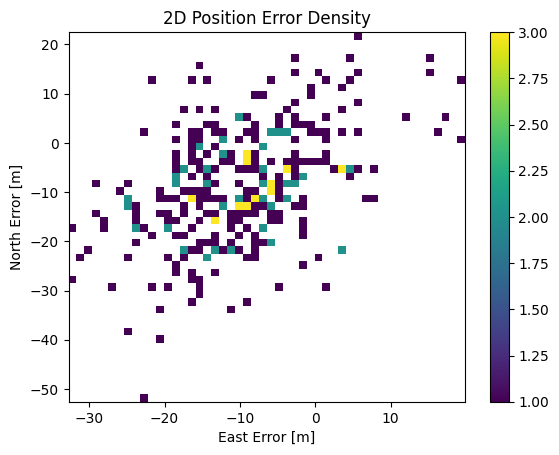

In [373]:
fig, mean_total_error, latex_table, stats = error_histogram(nmea_data, state_ekf_corr)
print(f"Mean total error is: {mean_total_error}")

**Plotting Residuals**

In [374]:
# for the best WLS (atmosphere) solved states compared to the full_states
glp.solve_residuals(atmospheric_full_states, wls_estimate_atmosphere, inplace=True)
# this adds a new residuals row to atmospheric full states

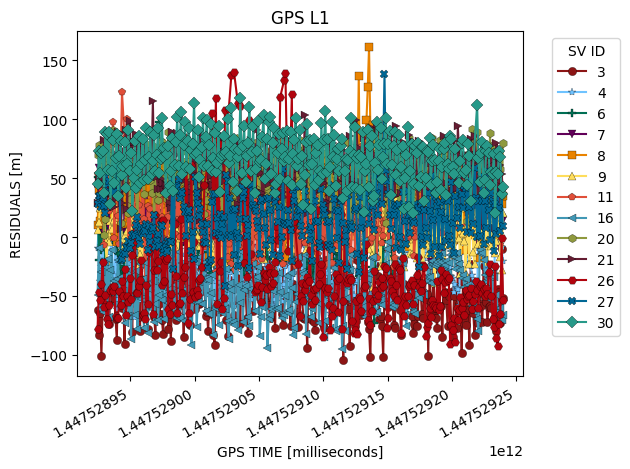

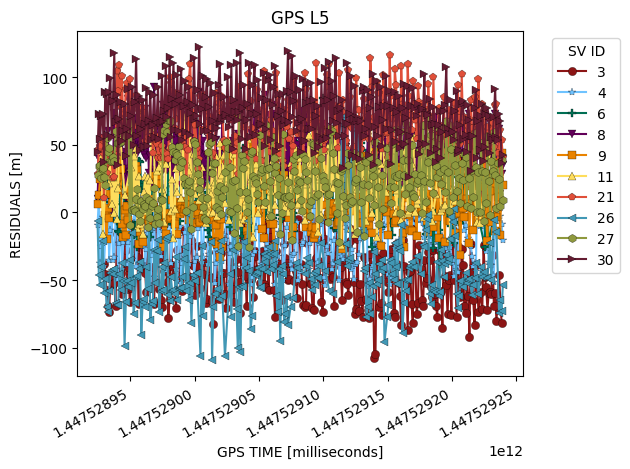

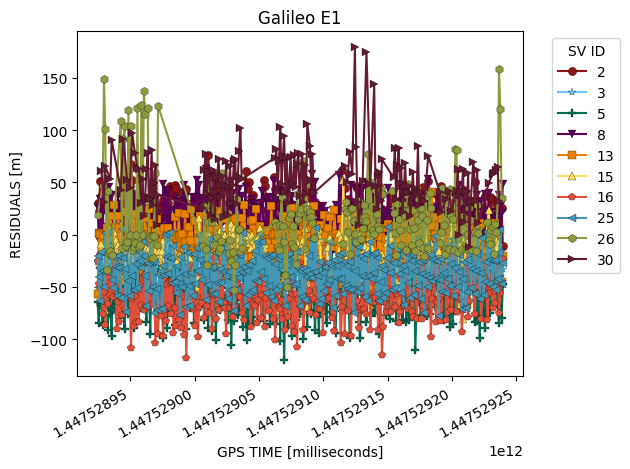

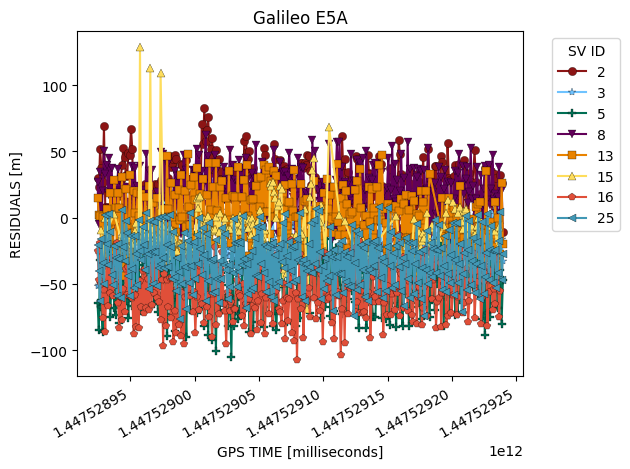

In [375]:
figs = glp.plot_metric_by_constellation(atmospheric_full_states, "gps_millis", "residuals_m")

In [376]:
# for the best EKF (atmosphere corr) solved states compared to the full_states with iono and tropo corrs
glp.solve_residuals(atmospheric_full_states, state_ekf_corr, inplace=True)
# this adds a new residuals row to atmospheric full states

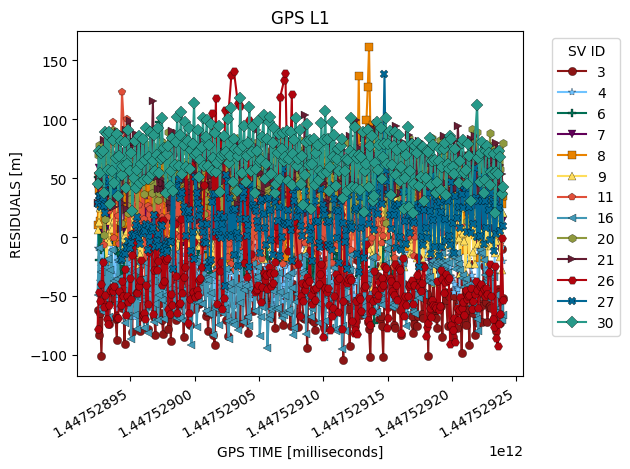

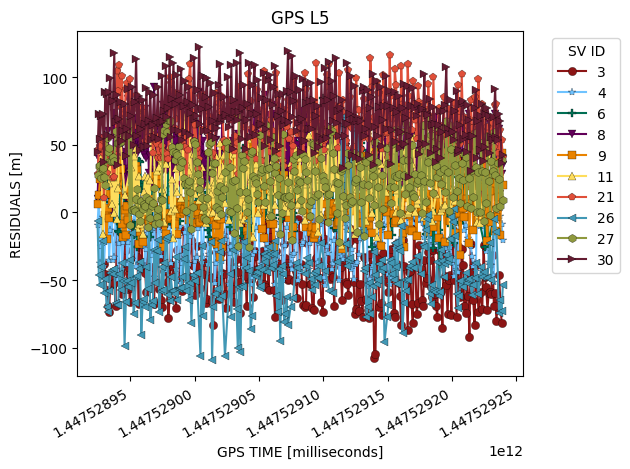

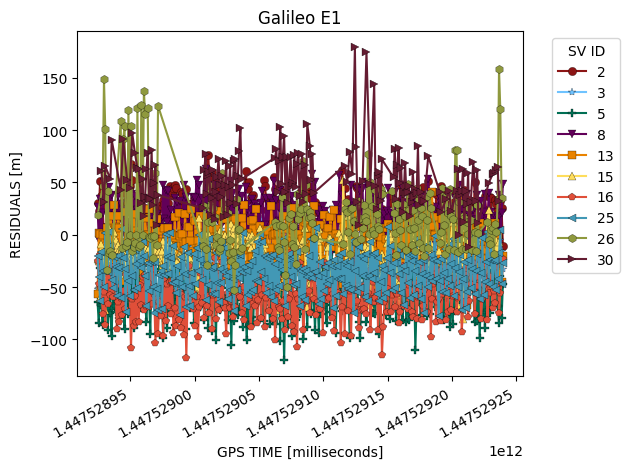

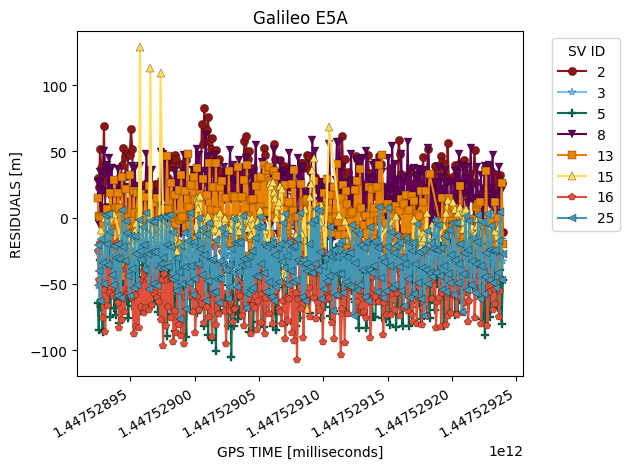

In [377]:
figs = glp.plot_metric_by_constellation(atmospheric_full_states, "gps_millis", "residuals_m")

**DOP Plotting**

In [378]:
# get dop values for cropped and uncropped daytime and nighttime data of the oval
# first nighttime because that is the data currently loaded

In [379]:
# get the dops as matrices
nav_dop_mat = glp.get_dop(navstates_sagnac, GDOP= True, HDOP=True, VDOP=True,
                          PDOP=True, TDOP=True, dop_matrix=True)
cropped_nav_dop_mat = glp.get_dop(cropped_navstates_sagnac, GDOP= True, HDOP=True, VDOP=True,
                          PDOP=True, TDOP=True, dop_matrix=True)

In [380]:
# print(nav_dop_mat)
# print(cropped_nav_dop_mat)

In [381]:
def plot_dop_matrix(H, cmap='RdBu_r', vmin=-0.75, vmax=0.75,
                    symmetric_color=True, label_nums=True):
    if symmetric_color:
        if (vmin is not None) or (vmax is not None):
            if not np.isclose(np.abs(vmin), np.abs(vmax)):
                raise ValueError(f"Cannot force symmetric color since vmin ({vmin}) is not of equal magnitude to vmax ({vmax})")
        else:
            # Estimate the vmin and vmax from values
            vmax = np.max(np.abs(H))
            vmin = - vmax

    # Plot the matrix as an image
    plt.imshow(H, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar()

    # Set the tick marks
    ticks = [0, 1, 2, 3]
    tick_labels = ["East", "North", "Up", "Time"]
    plt.xticks(ticks, tick_labels)
    plt.yticks(ticks, tick_labels)

    # Label the numbers
    if label_nums:
        for (j,i), label in np.ndenumerate(H):
            plt.text(i,j, f"{label:.3f}", ha='center', va='center')

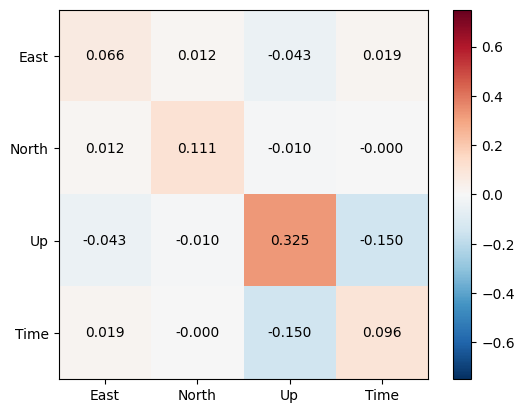

In [382]:
dop_accumulator = []

for timestamp, _, nav_dop_mat_subset in glp.loop_time(nav_dop_mat, 'gps_millis'):

    labels = glp.get_enu_dop_labels()

    dop_matrix_splat = np.array(
        [nav_dop_mat_subset[f'dop_{label}'] for label in labels]
    )

    H = glp.unsplat_dop_matrix(dop_matrix_splat)
    dop_accumulator.append(H)

# Stack into (T, 4, 4)
dop_stack = np.stack(dop_accumulator, axis=0)

# Time-averaged DOP matrix (4×4)
H_mean = np.mean(dop_stack, axis=0)

plot_dop_matrix(H_mean)


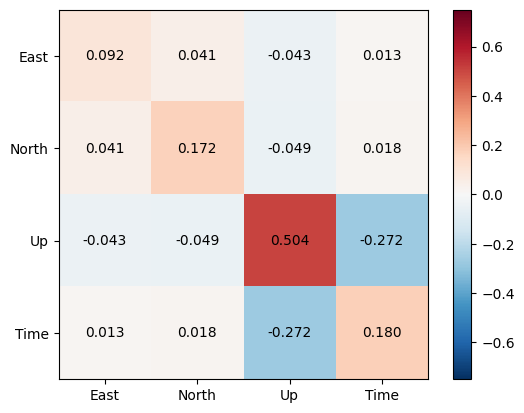

In [383]:
dop_accumulator_cropped = []

for timestamp, _, nav_dop_mat_subset in glp.loop_time(cropped_nav_dop_mat, 'gps_millis'):

    labels_cropped = glp.get_enu_dop_labels()

    dop_matrix_splat_cropped = np.array(
        [nav_dop_mat_subset[f'dop_{label}'] for label in labels_cropped]
    )

    H = glp.unsplat_dop_matrix(dop_matrix_splat_cropped)
    dop_accumulator_cropped.append(H)

# Stack into (T, 4, 4)
dop_stack_cropped = np.stack(dop_accumulator_cropped, axis=0)

# Time-averaged DOP matrix (4×4)
H_mean_cropped = np.mean(dop_stack_cropped, axis=0)

plot_dop_matrix(H_mean_cropped)